# 1) LINEAR REGRESSION

**In the below example, we will be working on a housing dataset trying to create a model to predict housing prices based upon the existing features**

In [ ]:
import pandas as pd
import numpy as np

df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6ML Practicals/USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [ ]:
df.describe()  #---gives an account of statistical numbers of the dataframe

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


Divide the dataset into data and labels
---

In [ ]:
X=df[['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population']]
y=df['Price']

Divide the dataset into train and test dataset
---

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.4,random_state=101)
#---random_state gives us the randomness in the split of the dataset
X_train
y_train

1303    1.489648e+06
1051    1.183015e+06
4904    1.547889e+06
931     1.186442e+06
4976    1.340344e+06
            ...     
4171    7.296417e+05
599     1.599479e+06
1361    1.102641e+06
1547    8.650995e+05
4959    2.108376e+06
Name: Price, Length: 3000, dtype: float64

Create and Train the Model
---

In [ ]:
from sklearn.linear_model import LinearRegression

lm=LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

Evaluating the Model
---

In [ ]:
print(lm.intercept_)
#---returns the intercept of the model

-2640159.7968526958


In [ ]:
lm.coef_
#---returns the coefficient of each feature

array([2.15282755e+01, 1.64883282e+05, 1.22368678e+05, 2.23380186e+03,
       1.51504200e+01])

In [ ]:
X_train.columns

Index(['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
       'Avg. Area Number of Bedrooms', 'Area Population'],
      dtype='object')

create the dataframe of the coefficients and their corresponding features
---

In [ ]:
cdf=pd.DataFrame(lm.coef_,X.columns,columns=['Coeff'])
cdf

,Coeff
Avg. Area Income,21.528276
Avg. Area House Age,164883.282027
Avg. Area Number of Rooms,122368.678027
Avg. Area Number of Bedrooms,2233.801864
Area Population,15.150420


Predictions
---

In [ ]:
predictions=lm.predict(X_test)
print(predictions)
#----prints the predicted prices of the test data

[1260960.70567627  827588.75560329 1742421.24254344 ...  372191.40626917
 1365217.15140898 1914519.5417888 ]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


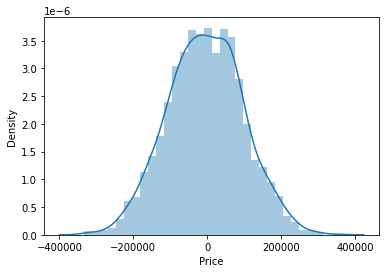

In [ ]:
import seaborn as sns

sns.distplot((y_test-predictions))
#---Plotting the residuals i.e, |Original values -predicted values|
#---If you have normally distributed residuals then the model is correct choice

In [ ]:
print('Train Score: ', lm.score(X_train, y_train))
print('Test Score: ', lm.score(X_test, y_test))

Train Score:  0.9181223200568411
Test Score:  0.9176824009649241


Evaluating Metrics
---

## Regression Evaluation Metrics


Here are three common evaluation metrics for regression problems:

**Mean Absolute Error** (MAE) is the mean of the absolute value of the errors:

$$\frac 1n\sum_{i=1}^n|y_i-\hat{y}_i|$$

**Mean Squared Error** (MSE) is the mean of the squared errors:

$$\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

**Root Mean Squared Error** (RMSE) is the square root of the mean of the squared errors:

$$\sqrt{\frac 1n\sum_{i=1}^n(y_i-\hat{y}_i)^2}$$

Comparing these metrics:

- **MAE** is the easiest to understand, because it's the average error.
- **MSE** is more popular than MAE, because MSE "punishes" larger errors, which tends to be useful in the real world.
- **RMSE** is even more popular than MSE, because RMSE is interpretable in the "y" units.

All of these are **loss functions**, because we want to minimize them.

In [ ]:
from sklearn import metrics

MAE=metrics.mean_absolute_error(y_test,predictions)
MSE=metrics.mean_squared_error(y_test,predictions)
RMSE=np.sqrt(MSE)
print('MAE=',MAE)
print('MSE=',MSE)
print('RMSE=',RMSE)



MAE= 82288.22251914942
MSE= 10460958907.208977
RMSE= 102278.82922290897




```
# This is formatted as code
```

# 2) Polynomial Regression

**Comparing Linear Vs polynomial**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/6ML Practicals/Position_Salaries.csv')
print(dataset.head())
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


## Training the Linear Regression model on the whole dataset

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)

LinearRegression()

## Training the Polynomial Regression model on the whole dataset

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly_reg = PolynomialFeatures(degree = 4)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)

LinearRegression()

-----Arguments----

PolynomialFeatures(
    degree=2 (---degree of polynomial features),
    
    interaction_only=False(produces interaction features if true, ignores x[1] ^2 or x[1]^3),
    
    include_bias=True(---If True (default),then include a bias column, the feature in which all polynomial powers are zero),
    
)

## Visualising the Linear Regression results

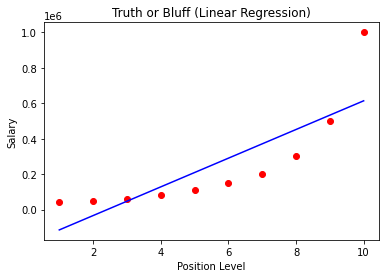

In [ ]:
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg.predict(X), color = 'blue')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

## Visualising the Polynomial Regression results

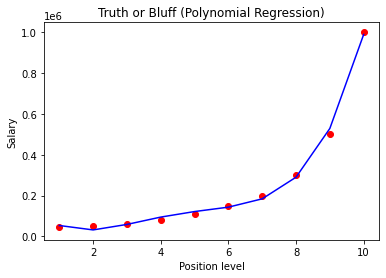

In [ ]:
plt.scatter(X, y, color = 'red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color = 'blue')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.show()

# 3) Support Vector Regression (SVR)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset = pd.read_csv('Position_Salaries.csv')
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

from sklearn.svm import SVR
regressor = SVR(kernel = 'rbf')
regressor.fit(X, y)
regressor.predict([[6.5]])

array([130001.82883924])

-----Arguments----

SVR(
    kernel='rbf' (---'linear', 'poly', 'rbf', 'sigmoid', 'precomputed' or a callable.default='rbf'),
    
    degree=3(--- If we are using 'poly' kernel then it has to be specified, otherwise ignored by other kernels),
    
    gamma='scale'(---If gamma is large, then variance is small implying the support vector does not have wide-spread influence. large gamma leads to high bias and low variance models, and vice-versa.
    {'scale', 'auto'} ,Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
    If gamma='scale' then it uses 1 / (n_features * X.var()) and gamma='auto the it uses 1 / n_features),
    
    coef0=0.0 (---Independent term in kernel function.Significant for 'poly' and 'sigmoid'),
    
    tol=0.001 (---Tolerance for stopping criterion.default=1e-3),
    
    C=1.0 (---C is the parameter for the soft margin cost function, which controls the influence of each individual support vector; this process involves trading error penalty for stability.regularization parameter,The strength of the regularization is inversely proportional to C.default=1),
    
    epsilon=0.1 (---It controls the width of the ε-insensitive zone, used to fit the training data. The value of ε can affect the number of support vectors used to construct the regression function. The bigger ε, the fewer support vectors are selected. Even bigger ε-values results in more flat estimates.It specifies the epsilon-tube within which no penalty is associated in the training loss function with points predicted within a distance epsilon from the actual value),
     
    shrinking=True,
    
    cache_size=200 (---Specify the size of the kernel cache (in MB)),
    
    verbose=False,
    
    max_iter=-1 (---Hard limit on iterations within solver, or -1 for no limit.default=-1),
)
